In [25]:
import pandas as pd

# for training
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt

import seaborn as sns


# train_test split
from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score

In [ ]:
# Data loading

# Data Preprocessing
# check null data
# check case problem
# go visualizations to check the relationship between cat and target variables
# 1. Gender -- Ins. Premium
# 2. smoker -- Ins. Premium - ?? Box Plot
# 3. Region -- Ins. Premium - Box Plot -- Not an important feature 
# Put the conclusions


# convert categorical ones into numerical

# Train and Test Split

# Linear Regression - Fit
# Predict (X_test)---> ypred

# r2 Score --> explained variance

# normality between ytrue and ypred - kde
# homoscedasticity - scatter plot

# Single prediction -  Insurance Premium 

# Streamlit Application - Try to upload it on Github Profile

# Deploy it on streamlit Public Cloud Server

In [5]:
# Data loading
df = pd.read_csv("insurance 1.csv")

df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [6]:
# Data Preprocessing
# check null data
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
# check values
print(df['sex'].unique())
print(df['smoker'].unique())
print(df['region'].unique())

<ArrowStringArray>
['female', 'male']
Length: 2, dtype: str
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str
<ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


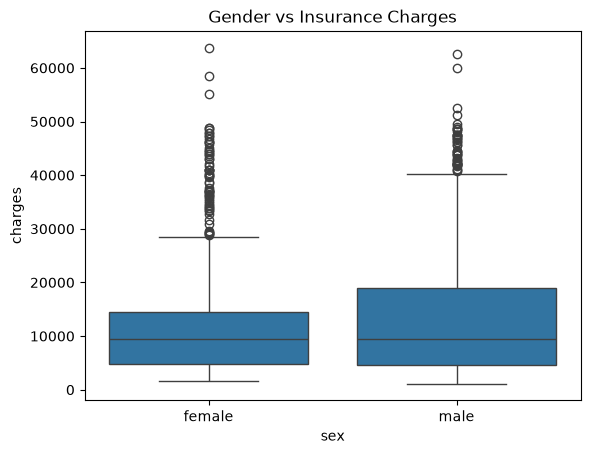

In [10]:
# go visualizations to check the relationship between cat and target variables
# 1. Gender -- Ins. Premium

sns.boxplot(x='sex', y='charges', data=df)
plt.title('Gender vs Insurance Charges')
plt.show()


#The insurance charges for males and females are very similar.
#There is a large overlap between the two distributions.
#Therefore, gender does not appear to be a strong predictor of insurance charges.

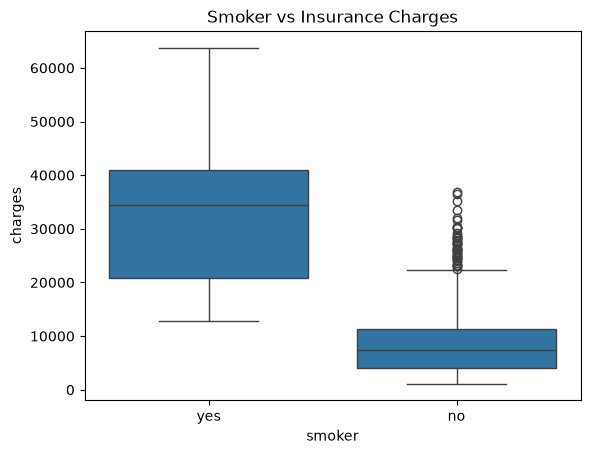

In [11]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Smoker vs Insurance Charges')
plt.show()

#Smokers have significantly higher insurance charges than non-smokers.
#There is a clear separation between the two groups.
#Therefore, smoker status is one of the most important features affecting insurance charges.

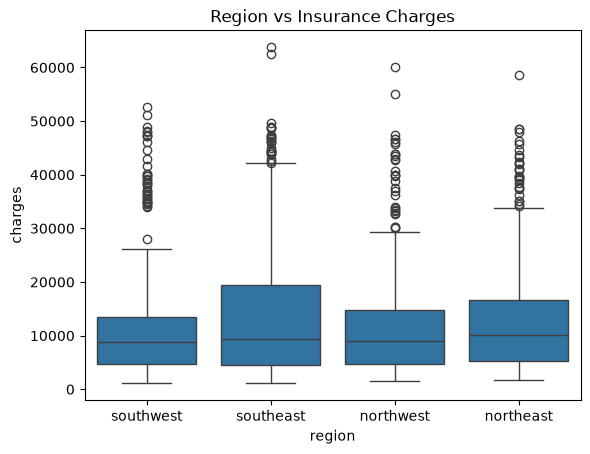

In [13]:
sns.boxplot(x='region', y='charges', data=df)
plt.title('Region vs Insurance Charges')
plt.show()


#Insurance charges are relatively similar across all regions.
#The distributions overlap considerably.
#Therefore, region does not appear to be a strong predictor of insurance charges.


In [17]:
df = pd.get_dummies(df,dtype=int, drop_first=True)

df 

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,30,3,10600,1,0,1,0,0
1334,18,31,0,2205,0,0,0,0,0
1335,18,36,0,1629,0,0,0,1,0
1336,21,25,0,2007,0,0,0,0,1


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,30,3,10600,1,0,1,0,0
1334,18,31,0,2205,0,0,0,0,0
1335,18,36,0,1629,0,0,0,1,0
1336,21,25,0,2007,0,0,0,0,1


In [19]:
 #train & test 

# Features
X = df.drop('charges', axis=1)

# Target
y = df['charges']

In [20]:
print(X.head())
print(y.head())

   age  bmi  children  sex_male  smoker_yes  region_northwest  \
0   19   27         0         0           1                 0   
1   18   33         1         1           0                 0   
2   28   33         3         1           0                 0   
3   33   22         0         1           0                 1   
4   32   28         0         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  
0    16884
1     1725
2     4449
3    21984
4     3866
Name: charges, dtype: int64


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

#test_size
#80% Training Data
#20% Testing Data
#random_state=42 Ensures the split is always the same each time you run the code.

In [23]:
#training
model = LinearRegression()
#fit() trains the model using the training data.
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 257.1 , 335.63, 427.59,...,-364.21,-667.64,-819.62]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.173e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [24]:

y_pred = model.predict(X_test)
y_pred

array([ 9087.64215363,  7232.55948323, 36744.39282136,  9390.86060464,
       26835.96961506, 10700.88438873,   176.85511159, 16763.42629132,
        1176.75821394, 11169.05006058, 28141.94818892,  9355.95788892,
        5221.40321606, 38448.8671946 , 40094.17744513, 36935.83914845,
       15154.15405998, 35854.24430695,  9256.40504231, 31345.37256898,
        3720.33899543, 10086.00383365,  2389.24817343,  7018.12055439,
       11443.40843791, 12895.76372111, 14625.6227313 ,  6201.46301286,
        9937.46817478,  2284.12664592,  9180.25612059, 12967.21335176,
        4415.21189286,  3280.78184264,  4616.51137491, 12914.07103691,
        2005.75807266,  8668.775376  , 33415.56094315, 32673.29028852,
        3873.19203608,  4379.17387366, 14024.82770535, 11450.34188499,
        8673.91733215, 12093.78520875,  5238.19686233,  3218.05521838,
       35328.14327403,  9166.62577563, 15884.51962992,  2376.08281379,
       12380.50385494,  1609.23655956, 13396.31680531, 12705.29630435,
      

In [26]:

r2 = r2_score(y_test, y_pred)

print(r2)

0.7837888448800693


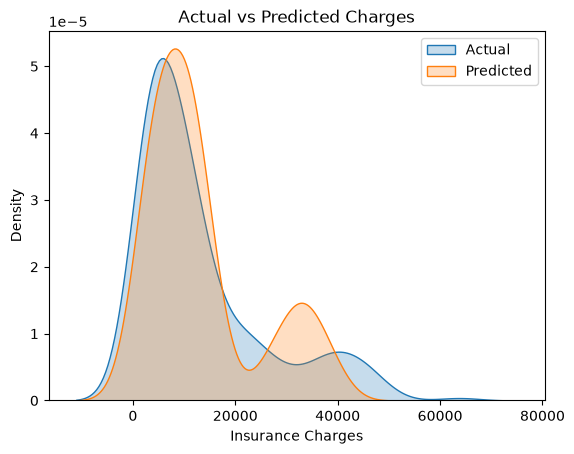

In [28]:
# normality between ytrue and ypred - kde
sns.kdeplot(y_test, label='Actual', fill=True)
sns.kdeplot(y_pred, label='Predicted', fill=True)

plt.xlabel('Insurance Charges')
plt.title('Actual vs Predicted Charges')
plt.legend()
plt.show()

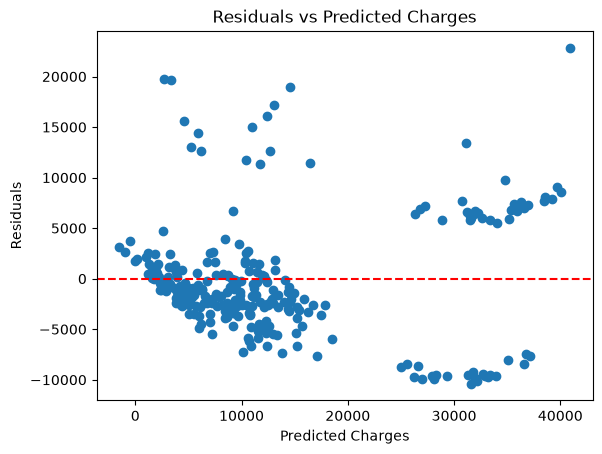

In [29]:
# homoscedasticity - scatter plot
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Charges')
plt.show()

In [30]:
print(X.columns)

Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='str')


In [32]:
#Create one customer using the same column names:
new_customer = pd.DataFrame({
    'age': [35],
    'bmi': [28.5],
    'children': [1],
    'sex_male': [0],
    'smoker_yes': [0],
    'region_northwest': [0],
    'region_southeast': [1],
    'region_southwest': [0]
})

In [38]:
prediction = model.predict(new_customer)[0]

print(
    f'Predicted Insurance Premium: ${prediction:,.2f}' #2f deux chiffer apres la virgule
)

Predicted Insurance Premium: $6,596.16


In [40]:
import joblib

joblib.dump(model, 'insurance_model.pkl')

#Your Streamlit application will load this saved model.

['insurance_model.pkl']